In [ ]:
#Jnomics Media - Data Analysis Test - TASK 2: Funnel
#by Hanif Maulana Abdullah

#TASK 2.1 First Subs Conversion Rate

In [1]:
#TASK 2.1 First Subs Conversion Rate
#using registrations csv
#import library and csv
import pandas as pd #for table
pd.set_option('display.expand_frame_repr', False) #to show dataframe in fully horizontal (no wrap)

#upload the csv to gdrive, share link to public:
url_reg="https://drive.google.com/uc?export=download&id=19BlrBP71Go6nxBg-vF9KT5jeR1giYHW4"
df_reg=pd.read_csv(url_reg) #read csv file as dataFrame
#print(df_reg.head()) #check table as dataFrame

#make sure dataframe lists format are datetime, so math operations can work
df_reg['registration_date'] = pd.to_datetime(df_reg['registration_date'])
df_reg['first_sub_date'] = pd.to_datetime(df_reg['first_sub_date'])

# create new column: first_sub - registration
df_reg['days_to_sub'] = (df_reg['first_sub_date'] - df_reg['registration_date']).dt.days
df_reg['days_to_sub'] = df_reg['days_to_sub'].astype('Int64')

#labeling which user is subs or not
df_reg['status'] = df_reg['days_to_sub'].notna().map({True: 'subs', False: 'not subs'})
#print(df_reg.head())

#groupby status
subs_count = df_reg.groupby('status').size().reset_index(name='count') #count subs vs not subs

#convert device count to percentage
subs_count['total'] = subs_count['count'].sum() #total count per device
subs_count['convert rate (%)'] = round((subs_count['count'] / subs_count['total']) * 100, 2) #convert to percentage
print(subs_count)

     status  count  total  convert rate (%)
0  not subs   1666   3000             55.53
1      subs   1334   3000             44.47


From here, we know that there are 44.47% users who converted to a paid subscriptions. Data used here is from all the time (3000 users), not only for particular period.

#TASK 2.2 Median Time of Days to Subs

In [2]:
#TASK 2.2 Finding Median
#we will only work for users who have 'subs' status
only_subs = df_reg[df_reg['status'] == 'subs'].reset_index()
#print(only_subs)

#sorting from shortest to longest days before subs
only_subs = only_subs.sort_values(by='days_to_sub')
#print(only_subs)

#find the median days
median_days = only_subs['days_to_sub'].median()
median_days = int(median_days)
print('Median time to subs is', median_days, 'days')

Median time to subs is 4 days


We find that the median time for users to convert to subs is 4 days.

#TASK 2.3 Conversion Speed ~ Retention?

In [3]:
#TASK 2.3 Conversion Speed related to Retention?
#create conversion speed: longest day --> slow speed
#sort days_to_sub as descending format: slow to fast conversion speed
only_subs = only_subs.sort_values(by='days_to_sub', ascending=False)
only_subs2 = only_subs.rename(columns={'days_to_sub': 'conversion_time'})
print(only_subs2)

      index   user_id registration_date first_sub_date  conversion_time status
727    1647  u_001647        2025-04-28     2025-06-14               47   subs
291     648  u_000648        2024-09-24     2024-11-08               45   subs
1031   2344  u_002344        2025-11-07     2025-12-20               43   subs
1113   2501  u_002501        2025-12-10     2026-01-21               42   subs
836    1909  u_001909        2025-07-07     2025-08-18               42   subs
...     ...       ...               ...            ...              ...    ...
762    1735  u_001735        2025-05-22     2025-05-22                0   subs
646    1485  u_001485        2025-03-23     2025-03-23                0   subs
29       56  u_000056        2024-04-13     2024-04-13                0   subs
1326   2965  u_002965        2026-03-20     2026-03-20                0   subs
1327   2967  u_002967        2026-03-21     2026-03-21                0   subs

[1334 rows x 6 columns]


In [4]:
#using subscriptions csv
#import library and csv
import pandas as pd #for table
pd.set_option('display.expand_frame_repr', False) #to show dataframe in fully horizontal (no wrap)

#upload the csv to gdrive, share link to public:
url_subs="https://drive.google.com/uc?export=download&id=1zOerxqcMLhEChUNOMQQpKLuUThsQZ1I0"
df_subs=pd.read_csv(url_subs) #read csv file as dataFrame

#erase every multiplicated user_id, we only use the newest end_date
sorted_subs = df_subs.sort_values(by='start_date')
cleaned_subs = sorted_subs.drop_duplicates(subset='user_id', keep='first')
#print(cleaned_subs)

#sort 'subs_only2' and 'cleaned_subs' dataframe by user_id (both have same rows now)
only_subs2 = only_subs2.sort_values(by='user_id')
cleaned_subs = cleaned_subs.sort_values(by='user_id').reset_index()
#print(only_subs2)
#print(cleaned_subs)

#pickup end_date from cleaned_subs, merge to only_subs3
only_subs3 = only_subs2.merge(cleaned_subs[['user_id', 'end_date']], on='user_id')
#print(only_subs3)

#replace end_date: NaN/NaT with 2026-04-01 (first day after the given period)
only_subs3['end_date'] = only_subs3['end_date'].fillna(pd.Timestamp('2026-04-01'))
#There are 445 NaN (if not mistaken), one-thirds of data

#make sure dataframe lists format are datetime, so math operations can work
only_subs3['first_sub_date'] = pd.to_datetime(only_subs3['first_sub_date'])
only_subs3['end_date'] = pd.to_datetime(only_subs3['end_date'])

#create new columns (in month)
only_subs4 = only_subs3.copy()
only_subs4['first_sub_month'] = pd.to_datetime(only_subs4['first_sub_date']).dt.to_period('M')
only_subs4['end_month'] = pd.to_datetime(only_subs4['end_date']).dt.to_period('M')
#print(only_subs4)

#create new column: retention_time (in month) = end_month - first_sub_month
only_subs4['retention_time'] = (only_subs4['end_month'] - only_subs4['first_sub_month']).apply(lambda x: x.n if pd.notna(x) else None)
only_subs4['retention_time'] = only_subs4['retention_time'].astype('Int64')
only_subs4['retention_time'] = only_subs4['retention_time'].replace(0, 1)
#replace retention_time =0 to =1,
#because it contains users who subs at 1st day, but churn at end of the month
#print(only_subs4)

#pick only user_id, conversion_time, retention_time then rename to each (day, month)
conv_ret = only_subs4[['user_id', 'conversion_time', 'retention_time']]
conv_ret2 = conv_ret.rename(columns={'conversion_time': 'conversion_time (day)',
                                     'retention_time':'retention_time (month)'})
print(conv_ret2)

       user_id  conversion_time (day)  retention_time (month)
0     u_000001                      3                       5
1     u_000002                      3                       8
2     u_000003                      2                       5
3     u_000006                      9                       1
4     u_000007                     17                      12
...        ...                    ...                     ...
1329  u_002970                      8                       1
1330  u_002982                      6                       1
1331  u_002983                      6                       1
1332  u_002993                      0                       1
1333  u_002995                      1                       1

[1334 rows x 3 columns]


Notes: Retention was calculated until the end of observation window (31 Mar 2026), so new users have shortest retention time possibility. (e.g. only 2 month, 1 month)

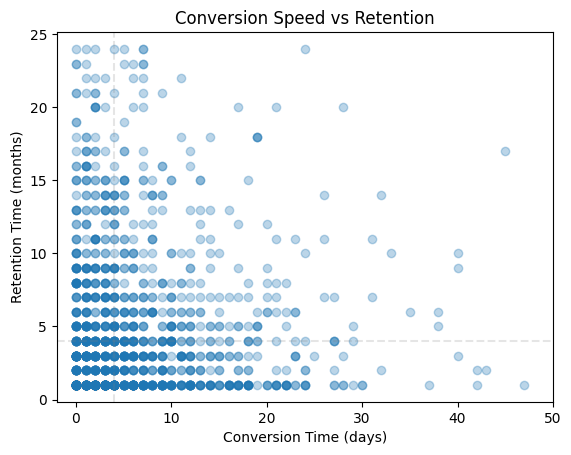

In [5]:
#plotting
import matplotlib.pyplot as plt

#plt.figure(figsize=(9, 5))
plt.scatter(conv_ret2['conversion_time (day)'], conv_ret2['retention_time (month)'], alpha=0.3)
plt.title('Conversion Speed vs Retention')
plt.xlabel('Conversion Time (days)')
plt.ylabel('Retention Time (months)')
plt.axvline(x=4, color='gray', linestyle='--', alpha=0.2)
plt.axhline(y=4, color='gray', linestyle='--', alpha=0.2)
plt.gca().set_axisbelow(True)
plt.xlim(-2, 50)
plt.show()

From the scatter plot, we can see that conversion time is inversely proportional to retention time. Therefore, fast conversion tends to churned later. Both correlated.

#TASK 2.4 What Source makes 'Best' Long-Term Subs?

**Definition:** Best Subscribers is user who subscribes and have high number of total 'minutes_spent'.

In [7]:
#TASK 2.4 Source that produce best subs?
#using engagement csv
#import library and csv
import pandas as pd #for table
pd.set_option('display.expand_frame_repr', False) #to show dataframe in fully horizontal (no wrap)

#prepare user_id who subs only
src = cleaned_subs[['user_id', 'acquisition_source']] #pick these metrics
src_ret = src.merge(only_subs4[['user_id', 'retention_time']], on='user_id')
#print(src)
#print(src_ret)

#import engagement csv data
url_engmt="https://drive.google.com/uc?export=download&id=1ljqGDsLkWAi_60nsj9TthK2CBHKqF3rz"
df_engmt=pd.read_csv(url_engmt) #read csv file as dataFrame
#print(df_engmt)

#create a filter: pick only user_id who subs, refer to src_ret df
df_engmt_filt = df_engmt[df_engmt['user_id'].isin(src_ret['user_id'])]
#print(df_engmt_filt)

#sum minutes_spent per user_id --> make new dataframe of 'user_id', 'total_minutes'
user_total = df_engmt_filt.groupby('user_id', as_index=False)['minutes_spent'].sum()
user_total2 = user_total.rename(columns={'minutes_spent': 'total_minutes'})
#print(user_total2)

#merge df user_total2 with src_ret
src_ret_tot = src_ret.merge(user_total2, on='user_id', how='left')
#if user_id cannot find in user_total2, then 'total_minutes'=0
src_ret_tot['total_minutes'] = src_ret_tot['total_minutes'].fillna(0)
src_ret_tot['total_minutes'] = src_ret_tot['total_minutes'].astype('Int64')
print(src_ret_tot)

#create 5 new df based on the 'acquisition_source'
src_dfs = {source: src_ret_tot[src_ret_tot['acquisition_source'] == source]
       for source in src_ret_tot['acquisition_source'].unique()}

#test print each source dataframe
#for source in src_ret_tot['acquisition_source'].unique():
#    print(src_dfs[source])

       user_id acquisition_source  retention_time  total_minutes
0     u_000001             social               5              0
1     u_000002              email               8              0
2     u_000003              promo               5              0
3     u_000006              promo               1              0
4     u_000007             social              12            204
...        ...                ...             ...            ...
1329  u_002970              promo               1             56
1330  u_002982              promo               1             31
1331  u_002983            organic               1             12
1332  u_002993              promo               1             47
1333  u_002995             social               1              0

[1334 rows x 4 columns]


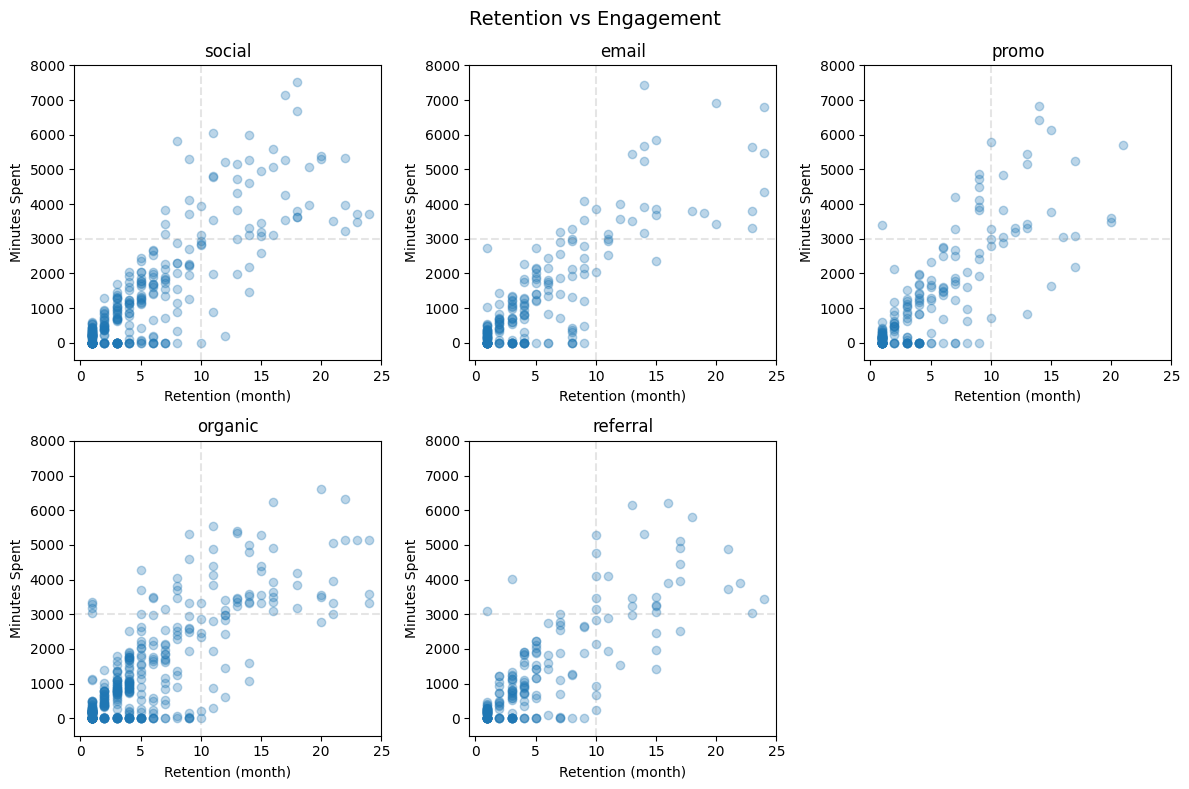

In [8]:
#plotting
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 3)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
]

for ax, (source, d) in zip(axes, src_dfs.items()):
    ax.scatter(d['retention_time'], d['total_minutes'], alpha=0.3)
    ax.set_title(source)
    ax.set_xlim(-0.5, 25)
    ax.set_ylim(-500, 8000)
    ax.axvline(x=10, color='gray', linestyle='--', alpha=0.2)
    ax.axhline(y=3000, color='gray', linestyle='--', alpha=0.2)
    ax.set_xlabel('Retention (month)')
    ax.set_ylabel('Minutes Spent')

fig.suptitle('Retention vs Engagement', fontsize=14)
plt.tight_layout()
plt.show()

We will focus on top-right side of these 5 scatter plot. This side representate the answer of the question: "What Source makes Best Long-Term Subs?". We can see that the loyal subscribers (long-term members and spent more times to engage) are mostly came from 'social' source. There are also some extreme long-term subscribers from 'organic' and 'email' sources but not spent much time rather than they who in 'social' groups. Lastly, best long-time subscribers who came from 'referal' and 'promo' sources remain the least and show similar behaviour.